# Stock Competition 2026 — input データ概要

input の20個のParquetがデータについてのノートブック。列単位の細かい仕様と採点ルールは [README](README.md#data) を参照。

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import HTML, display

INPUT_DIR = Path("input")
assert INPUT_DIR.is_dir(), (
    "stock_comp_2026 フォルダを作業ディレクトリにして実行してください。"
)

def input_parquets():
    # macOSが外付けドライブ等に作る「._*」メタデータファイルを除外する
    return sorted(
        path for path in INPUT_DIR.glob("*.parquet")
        if not path.name.startswith(".")
    )

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
plt.style.use("seaborn-v0_8-whitegrid")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for japanese_font in ["Hiragino Sans", "YuGothic", "BIZ UDGothic", "Noto Sans CJK JP"]:
    if japanese_font in available_fonts:
        plt.rcParams["font.family"] = japanese_font
        break
plt.rcParams.update({"figure.figsize": (12, 5), "axes.unicode_minus": False})

def display_no_index(frame):
    display(HTML(frame.to_html(index=False)))

print(f"input: {INPUT_DIR.resolve()}")
print(f"Parquet files: {len(input_parquets())}")

input: /Volumes/NX-P2SE1TB/stock_comp/Day2/stock_comp_2026/input
Parquet files: 20


## 1. 全体像と出典

出典は3系統。取得基準日は 2026-07-31。

| 出典 | ファイル | 内容 |
|---|---|---|
| [J-Quants](https://jpx-jquants.com/)（JPX総研の株式データAPI） | prices_daily_quotes / fins_statements / listed_info | 日次株価、決算短信サマリ、上場銘柄属性 |
| 運営が上記の価格データから計算 | raw_return_1day / beta_1day / raw_target_1day / target_1day / topix_return_1day | 始値→始値リターン、対市場β、予測ターゲット、市場リターン |
| 公開マクロ統計 | ecb_fx_rates / consumer_attitude_index | [ECB Data Portal](https://data.ecb.europa.eu/data/datasets/EXR) の為替参照レート、[内閣府「消費動向調査」](https://www.e-stat.go.jp/stat-search/files?toukei=00100405&tstat=000001014549)（e-Stat原本）の消費者態度指数 |

ユニバースは日本株498銘柄の固定リストで、各銘柄の上場期間だけ行がある。train は 2008-11-04〜2016-03-31、valid は 2016-04-01〜2026-07-31。

index の `Date` の意味はファイルごとに違う。株価・リターン系・listed_info は取引日、fins_statements は開示日、マクロ2表は利用可能になった日時。

In [2]:
DATASET_INFO = {
    "prices_daily_quotes": ("株価", "J-Quants", "Date × Code", "日次OHLCV（生値・調整後・前場・後場）"),
    "raw_return_1day": ("リターン", "運営算出（prices由来）", "Date × Code", "過去の始値→始値リターン（特徴量）"),
    "beta_1day": ("リターン", "運営算出（prices由来）", "Date × Code", "市場に対する120営業日ローリングβ"),
    "target_1day": ("ラベル", "運営算出（prices由来）", "Date × Code", "将来1日リターンから市場要因を除いた予測対象"),
    "raw_target_1day": ("ラベル", "運営算出（prices由来）", "Date × Code", "残差化前の将来1日リターン"),
    "topix_return_1day": ("市場", "運営算出（ETF4本を合成）", "Date", "TOPIX連動ETFから合成した市場リターン"),
    "listed_info": ("銘柄属性", "J-Quants", "Date × Code", "Point-in-Timeの業種・市場・規模等"),
    "fins_statements": ("財務", "J-Quants", "Disclosure Date × Code", "決算短信サマリ（開示イベント単位）"),
    "ecb_fx_rates": ("マクロ", "ECB", "Available Date × Pair", "ECB為替レート"),
    "consumer_attitude_index": ("マクロ", "内閣府（e-Stat）", "Available Date", "消費者態度指数（原数値）"),
}

def dataset_stem(file_name):
    return file_name.removesuffix("_train.parquet").removesuffix("_valid.parquet")

def index_names(schema):
    metadata = schema.metadata or {}
    if b"pandas" not in metadata:
        return []
    pandas_meta = json.loads(metadata[b"pandas"].decode("utf-8"))
    return [x for x in pandas_meta.get("index_columns", []) if isinstance(x, str)]

def parquet_date_bounds(parquet_file):
    date_pos = parquet_file.schema_arrow.get_field_index("Date")
    if date_pos < 0:
        return pd.NaT, pd.NaT
    mins, maxs = [], []
    for row_group_no in range(parquet_file.num_row_groups):
        stats = parquet_file.metadata.row_group(row_group_no).column(date_pos).statistics
        if stats is not None and stats.has_min_max:
            mins.append(pd.Timestamp(stats.min))
            maxs.append(pd.Timestamp(stats.max))
    return (min(mins), max(maxs)) if mins else (pd.NaT, pd.NaT)

records = []
for path in input_parquets():
    if not path.name.endswith("_train.parquet"):
        continue
    parquet_file = pq.ParquetFile(path)
    schema = parquet_file.schema_arrow
    idx = index_names(schema)
    date_min, date_max = parquet_date_bounds(parquet_file)
    stem = dataset_stem(path.name)
    group, source, grain, description = DATASET_INFO[stem]
    records.append({
        "file": path.name,
        "group": group,
        "source": source,
        "grain / index": " × ".join(idx) if idx else grain,
        "start": date_min,
        "end": date_max,
        "description": description,
    })

catalog = pd.DataFrame(records).sort_values(["group", "file"]).reset_index(drop=True)
display_no_index(catalog)

file,group,source,grain / index,start,end,description
consumer_attitude_index_train.parquet,マクロ,内閣府（e-Stat）,Date,2008-11-12 14:59:59+00:00,2016-03-08 14:59:59+00:00,消費者態度指数（原数値）
ecb_fx_rates_train.parquet,マクロ,ECB,Date × Pair,2008-10-31 15:00:00+00:00,2016-03-31 14:00:00+00:00,ECB為替レート
raw_target_1day_train.parquet,ラベル,運営算出（prices由来）,Date × Code,2008-11-04 00:00:00,2016-03-31 00:00:00,残差化前の将来1日リターン
target_1day_train.parquet,ラベル,運営算出（prices由来）,Date × Code,2008-11-04 00:00:00,2016-03-31 00:00:00,将来1日リターンから市場要因を除いた予測対象
beta_1day_train.parquet,リターン,運営算出（prices由来）,Date × Code,2008-11-04 00:00:00,2016-03-31 00:00:00,市場に対する120営業日ローリングβ
raw_return_1day_train.parquet,リターン,運営算出（prices由来）,Date × Code,2008-11-04 00:00:00,2016-03-31 00:00:00,過去の始値→始値リターン（特徴量）
topix_return_1day_train.parquet,市場,運営算出（ETF4本を合成）,Date,2008-11-04 00:00:00,2016-03-31 00:00:00,TOPIX連動ETFから合成した市場リターン
prices_daily_quotes_train.parquet,株価,J-Quants,Date × Code,2008-11-04 00:00:00,2016-03-31 00:00:00,日次OHLCV（生値・調整後・前場・後場）
fins_statements_train.parquet,財務,J-Quants,Date × Code,2008-11-03 15:00:00+00:00,2016-03-30 15:00:00+00:00,決算短信サマリ（開示イベント単位）
listed_info_train.parquet,銘柄属性,J-Quants,Date × Code,2008-11-04 00:00:00,2016-03-31 00:00:00,Point-in-Timeの業種・市場・規模等


## 2. 株価（prices_daily_quotes）

J-Quantsの日次株価。生OHLCVと制限値幅のほか、分割・併合を調整した `Adjustment*` 系列、前場 `Morning*`・後場 `Afternoon*` の内訳を持つ。生値は分割・併合で不連続になるので、時系列特徴量には調整後系列を使う。

,prices_train
rows,809636
start,2008-11-04 00:00:00
end,2016-03-31 00:00:00
unique codes,473
active codes on last train date,472
example code,13320
AdjustmentClose missing rate,0.0008918


,AdjustmentOpen,AdjustmentHigh,AdjustmentLow,AdjustmentClose,AdjustmentVolume,TurnoverValue
Date,,,,,,
2008-11-04,252,259,248,259,1.927e+06,4.899e+08
2008-11-05,265,268,258,266,2.474e+06,6.515e+08
2008-11-06,255,255,232,238,4.073e+06,9.889e+08
2008-11-07,235,244,229,237,2.496e+06,5.907e+08
2008-11-10,249,254,247,253,1.697e+06,4.243e+08


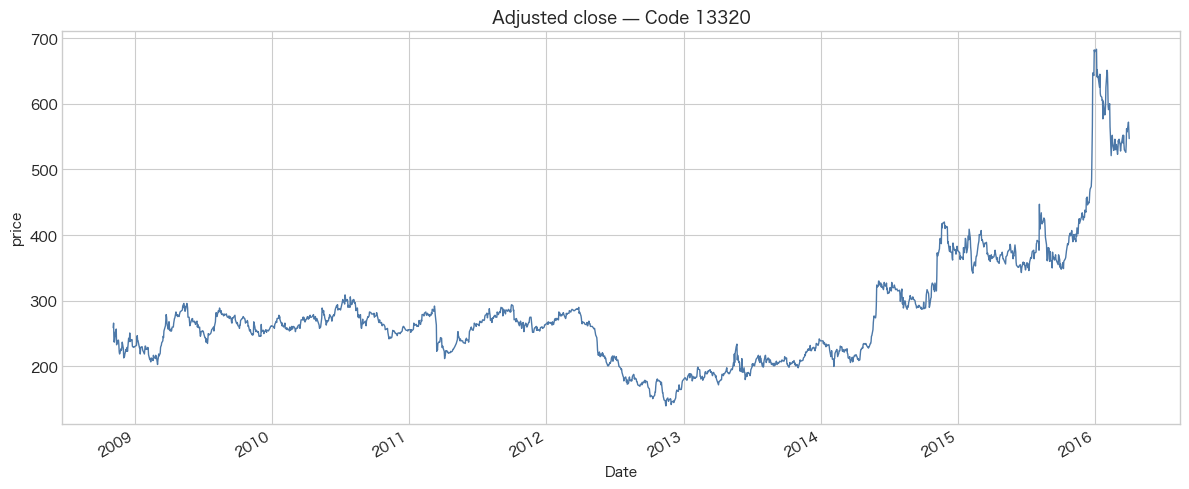

In [3]:
price_columns = [
    "AdjustmentOpen", "AdjustmentHigh", "AdjustmentLow",
    "AdjustmentClose", "AdjustmentVolume", "TurnoverValue"
]
prices = pd.read_parquet(INPUT_DIR / "prices_daily_quotes_train.parquet", columns=price_columns)
dates = prices.index.get_level_values("Date")
codes = prices.index.get_level_values("Code")
latest_train_date = dates.max()
active_train_codes = set(prices.xs(latest_train_date, level="Date").index.astype(str))
observation_counts = prices["AdjustmentClose"].notna().groupby(level="Code").sum()
example_code = str(observation_counts.idxmax())
example_price = prices.xs(example_code, level="Code").sort_index()

display(pd.Series({
    "rows": len(prices),
    "start": dates.min(),
    "end": dates.max(),
    "unique codes": codes.nunique(),
    "active codes on last train date": len(active_train_codes),
    "example code": example_code,
    "AdjustmentClose missing rate": prices["AdjustmentClose"].isna().mean(),
}, name="prices_train").to_frame())
display(example_price.head())

fig, ax = plt.subplots(figsize=(12, 5))
example_price["AdjustmentClose"].plot(ax=ax, color="#4C78A8", lw=1)
ax.set(title=f"Adjusted close — Code {example_code}", xlabel="Date", ylabel="price")
plt.tight_layout()
plt.show()



左は最も観測数が多い銘柄の調整後終値、右は日ごとの行数と価格が入っている銘柄数。行はあっても売買停止などで価格がNaNの日があり、上場期間しか行がないので日ごとの銘柄数も一定ではない。

## 3. リターン、β、予測ターゲット

いずれも運営が株価から計算した派生系列。時点 t で raw_return[t] は観測可能な過去リターン、raw_target[t] は raw_return[t+2] にあたる未来ラベル、target[t] はそこから beta[t+2] × topix_return[t+2] を引いた市場残差＝予測対象。target と raw_target は特徴量に入れない。

topix_return はTOPIX指数そのものではなく、TOPIX連動ETF4本（1305/1306/1308/1348）から全期間統一の式で合成した近似系列（指数実測値との相関 約0.90）。βもこの系列に対する値。

file,rows,non-null %,mean,std,p01,median,p99
raw_return_1day_train.parquet,809636,99.88,0.0006613,0.02321,-0.05996,0,0.06561
beta_1day_train.parquet,809636,99.32,1.017,0.423,0.1183,1.009,2.057
raw_target_1day_train.parquet,809636,99.89,0.0005955,0.02314,-0.05996,0,0.06503
target_1day_train.parquet,809636,99.31,0.0002984,0.01895,-0.04768,-0.0002147,0.05449
topix_return_1day_train.parquet,1814,100,0.0003513,0.01206,-0.03312,0.0005431,0.03234


raw target と residual target の相関: 0.8181


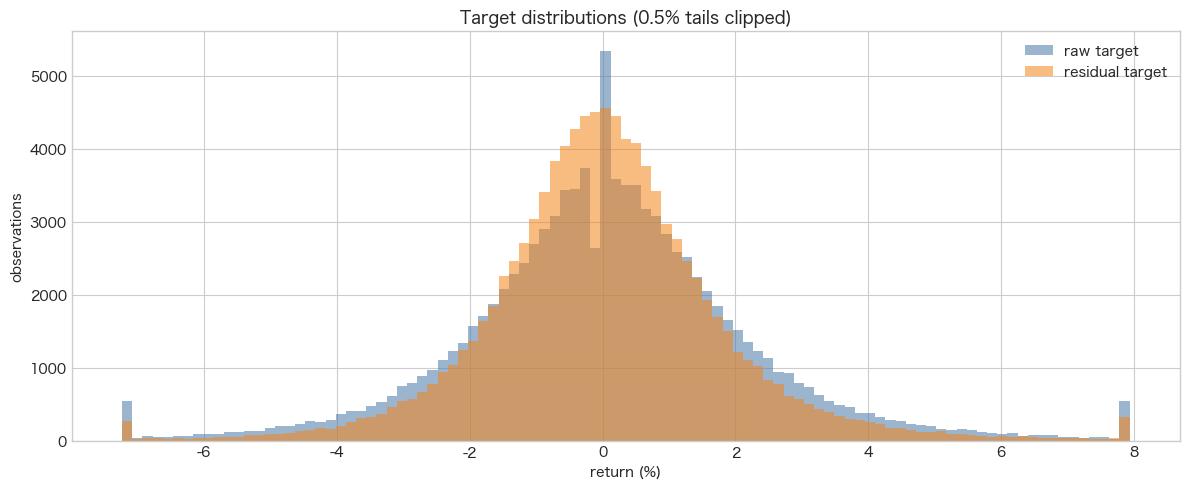

In [4]:
def scalar_panel_profile(file_name):
    panel = pd.read_parquet(INPUT_DIR / file_name, columns=["Return"])
    values = panel["Return"]
    result = {
        "file": file_name,
        "rows": len(panel),
        "non-null %": values.notna().mean() * 100,
        "mean": values.mean(),
        "std": values.std(),
        "p01": values.quantile(0.01),
        "median": values.median(),
        "p99": values.quantile(0.99),
    }
    return result

profile_files = [
    "raw_return_1day_train.parquet",
    "beta_1day_train.parquet",
    "raw_target_1day_train.parquet",
    "target_1day_train.parquet",
    "topix_return_1day_train.parquet",
]
return_profiles = pd.DataFrame([scalar_panel_profile(name) for name in profile_files])
display_no_index(return_profiles)

raw_target = pd.read_parquet(INPUT_DIR / "raw_target_1day_train.parquet", columns=["Return"]).rename(columns={"Return": "raw target"})
target = pd.read_parquet(INPUT_DIR / "target_1day_train.parquet", columns=["Return"]).rename(columns={"Return": "residual target"})
target_compare = raw_target.join(target, how="inner").dropna()
step = max(1, len(target_compare) // 100_000)
target_sample = target_compare.iloc[::step].head(100_000) * 100
lo = target_sample.quantile(0.005).min()
hi = target_sample.quantile(0.995).max()
plot_sample = target_sample.clip(lo, hi)

print(f"raw target と residual target の相関: {target_compare.corr().iloc[0, 1]:.4f}")
fig, ax = plt.subplots(figsize=(12, 5))
bins = np.linspace(lo, hi, 100)
ax.hist(plot_sample["raw target"], bins=bins, alpha=0.55, label="raw target", color="#4C78A8")
ax.hist(plot_sample["residual target"], bins=bins, alpha=0.55, label="residual target", color="#F58518")
ax.set(title="Target distributions (0.5% tails clipped)", xlabel="return (%)", ylabel="observations")
ax.legend()
plt.tight_layout()
plt.show()



ヒストグラムは残差化の前後で分布がどう変わるかを示す。末尾2営業日のラベルは未来の始値が無いのでNaN（異常ではない）。βも上場直後など120営業日の履歴が足りない区間はNaN。

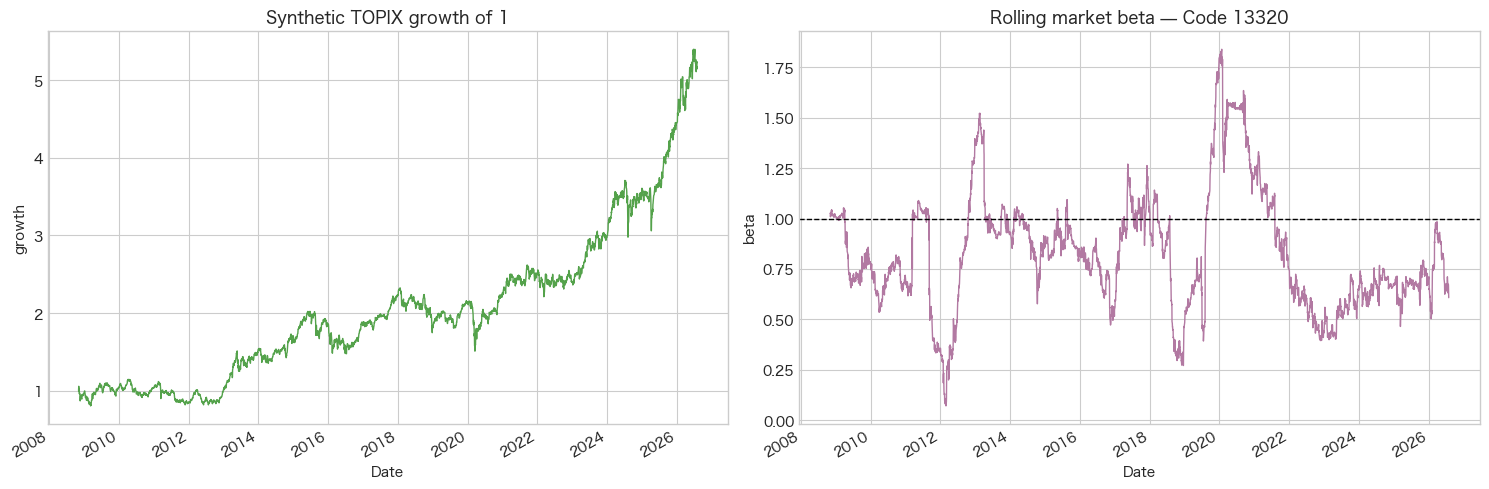

In [5]:
topix = pd.concat([
    pd.read_parquet(INPUT_DIR / "topix_return_1day_train.parquet"),
    pd.read_parquet(INPUT_DIR / "topix_return_1day_valid.parquet"),
]).sort_index()
beta_parts = []
for split in ["train", "valid"]:
    beta_part = pd.read_parquet(
        INPUT_DIR / f"beta_1day_{split}.parquet",
        columns=["Return"],
        filters=[("Code", "==", example_code)],
    )
    beta_parts.append(beta_part)
example_beta = pd.concat(beta_parts).sort_index()["Return"]
if isinstance(example_beta.index, pd.MultiIndex):
    example_beta = example_beta.droplevel("Code")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
market_growth = (1 + topix["Return"].fillna(0)).cumprod()
market_growth.plot(ax=axes[0], color="#54A24B", lw=1)
axes[0].set(title="Synthetic TOPIX growth of 1", xlabel="Date", ylabel="growth")
example_beta.plot(ax=axes[1], color="#B279A2", lw=1)
axes[1].axhline(1, color="black", lw=1, ls="--")
axes[1].set(title=f"Rolling market beta — Code {example_code}", xlabel="Date", ylabel="beta")
plt.tight_layout()
plt.show()



## 4. 銘柄属性と財務データ

listed_info は、各取引日にその時点でJ-Quantsで公開されていた全上場銘柄（約4,400）の属性（17/33業種・規模・市場区分など）。2022年の市場区分再編も当時のまま入っているので、最新時点の属性で過去を上書きせず、同じsplitの同じ Date × Code で完全一致結合する。ファイルが大きいので、ここではvalid最終日の1 row groupだけ読む。

listed_info latest date: 2026-07-31 / all listed: 4,444 / matched competition codes: 466


Date,Code,CompanyName,Sector17CodeName,Sector33CodeName,ScaleCategory,MarketCodeName
2026-07-31,13320,ニッスイ,食品,水産・農林業,TOPIX Mid400,プライム
2026-07-31,13330,Ｕｍｉｏｓ,食品,水産・農林業,TOPIX Mid400,プライム
2026-07-31,14140,ショーボンドホールディングス,建設・資材,建設業,TOPIX Mid400,プライム
2026-07-31,14170,ミライト・ワン,建設・資材,建設業,TOPIX Mid400,プライム
2026-07-31,16050,ＩＮＰＥＸ,エネルギー資源,鉱業,TOPIX Mid400,プライム
2026-07-31,17190,安藤・間,建設・資材,建設業,TOPIX Mid400,プライム
2026-07-31,17210,コムシスホールディングス,建設・資材,建設業,TOPIX Mid400,プライム
2026-07-31,18010,大成建設,建設・資材,建設業,TOPIX Mid400,プライム
2026-07-31,18020,大林組,建設・資材,建設業,TOPIX Mid400,プライム
2026-07-31,18030,清水建設,建設・資材,建設業,TOPIX Mid400,プライム


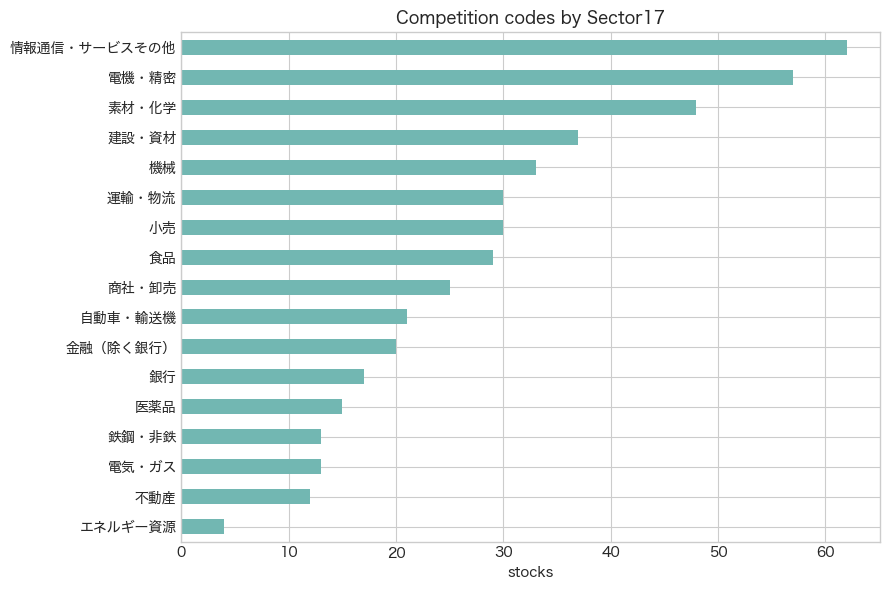

In [6]:
listed_file = pq.ParquetFile(INPUT_DIR / "listed_info_valid.parquet")
listed_latest = listed_file.read_row_group(listed_file.num_row_groups - 1).to_pandas().reset_index()
listed_comp = listed_latest[listed_latest["Code"].astype(str).isin(active_train_codes)].copy()

print(f"listed_info latest date: {listed_latest['Date'].min().date()} / all listed: {len(listed_latest):,} / matched competition codes: {len(listed_comp):,}")
display_no_index(
    listed_comp[["Date", "Code", "CompanyName", "Sector17CodeName", "Sector33CodeName", "ScaleCategory", "MarketCodeName"]]
    .head(10)
)

sector_counts = listed_comp["Sector17CodeName"].fillna("Unknown").value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
sector_counts.plot.barh(ax=ax, color="#72B7B2")
ax.set(title="Competition codes by Sector17", xlabel="stocks", ylabel="")
plt.tight_layout()
plt.show()



図はtrain最終日のコンペ銘柄をvalid最終日の属性に照合した参考値。上場廃止などがあるので498銘柄全部は一致しない。特徴量を作るときは各日の完全一致結合を使う。

### 財務データ（fins_statements）

J-Quantsの決算短信サマリを106列に整形したもの（`FiscalYear` と `Period` は配布時に追加した補助列）。売上高・利益・純資産・1株利益・会社予想・配当などがあり、株価と組み合わせると馴染みのある投資指標を作れる。各列の詳しい意味は [J-Quants ProのFinancial Summary仕様書](https://pro.jpx-jquants.com/datasets/5) を参照。ここではtrain最終日の株価と、その日までに開示された最新の財務値から次の3指標を計算する。

- **PBR（株価純資産倍率）** = 株価 ÷ 1株純資産（`BookValuePerShare`）
- **予想PER（株価収益率）** = 株価 ÷ 会社予想1株利益（`ForecastEarningsPerShare`）
- **予想配当利回り** = 会社予想年間1株配当（`ForecastDividendPerShareAnnual`）÷ 株価 × 100

index の `Date` は会計期間末ではなく開示日（tz-aware, Asia/Tokyo）。この例のように、その時点までに公表された値だけを使う。

Snapshot date: 2016-03-31 / stocks with prices: 472


,stocks,median
PBR (x),465,1.37
Forecast PER (x),450,17.14
Forecast dividend yield (%),465,1.79


,Close,BookValuePerShare,ForecastEarningsPerShare,PBR (x),Forecast PER (x),Forecast dividend yield (%)
Code,,,,,,
81290,"2,408","2,247",168.6,1.07,14.28,1.08
45360,"1,693",625.1,128.1,2.71,13.21,1.48
31160,"1,834","1,164",150.9,1.58,12.15,1.64
86300,"3,188","4,464",394.6,0.71,8.08,2.51
31410,"6,480","1,678",211.3,3.86,30.67,0.62
74530,2.38e+04,"5,175",810.4,4.6,29.37,0.92
95070,"1,509","1,488",39,1.01,38.69,1.33
63830,"1,897",972.8,115.3,1.95,16.46,1.58
45680,"2,502","1,893",109.8,1.32,22.8,2.8


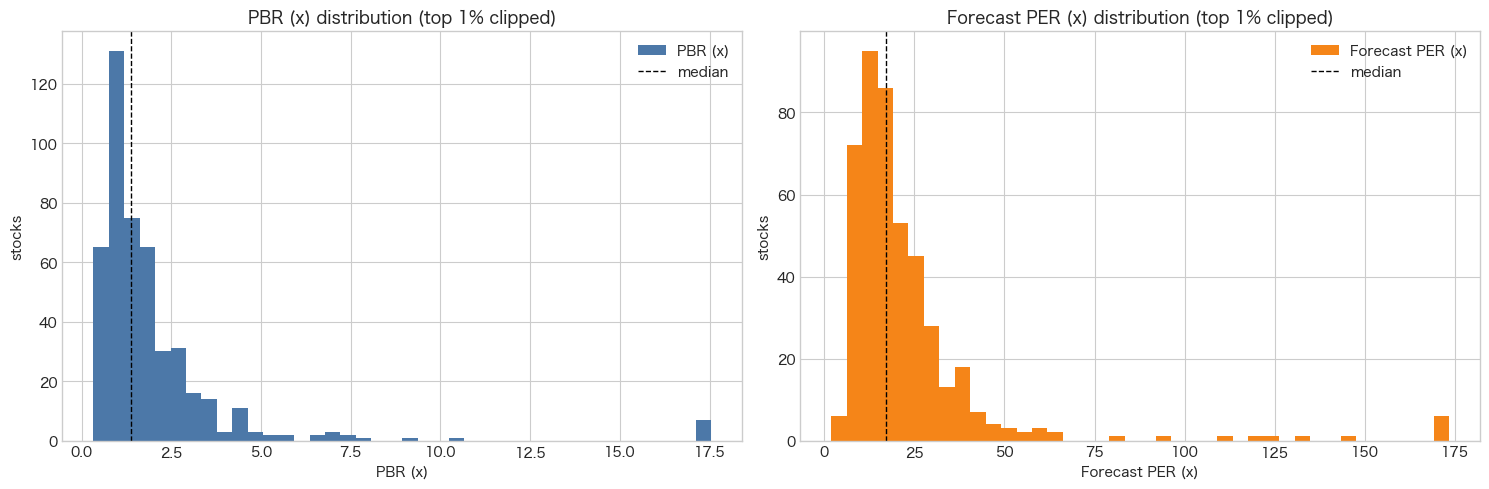

In [7]:
fundamental_columns = [
    "BookValuePerShare",
    "ForecastEarningsPerShare",
    "ForecastDividendPerShareAnnual",
]
fins = pd.read_parquet(
    INPUT_DIR / "fins_statements_train.parquet",
    columns=fundamental_columns,
).sort_index()

# 各銘柄について、train最終日までに開示された直近の値を取り出す
latest_fundamentals = (
    fins.groupby(level="Code", observed=True)[fundamental_columns]
    .last()
)
snapshot_prices = pd.read_parquet(
    INPUT_DIR / "prices_daily_quotes_train.parquet",
    columns=["Close"],
    filters=[("Date", "==", latest_train_date)],
).droplevel("Date")

indicators = snapshot_prices.join(latest_fundamentals, how="left")
indicators["PBR (x)"] = (
    indicators["Close"] / indicators["BookValuePerShare"]
).where(indicators["BookValuePerShare"] > 0)
indicators["Forecast PER (x)"] = (
    indicators["Close"] / indicators["ForecastEarningsPerShare"]
).where(indicators["ForecastEarningsPerShare"] > 0)
indicators["Forecast dividend yield (%)"] = (
    indicators["ForecastDividendPerShareAnnual"] / indicators["Close"] * 100
).where(indicators["Close"] > 0)

indicator_columns = ["PBR (x)", "Forecast PER (x)", "Forecast dividend yield (%)"]
indicator_summary = pd.DataFrame({
    "stocks": indicators[indicator_columns].notna().sum(),
    "median": indicators[indicator_columns].median(),
}).round(2)
print(f"Snapshot date: {latest_train_date.date()} / stocks with prices: {len(indicators):,}")
display(indicator_summary)

example_indicators = (
    indicators.dropna(subset=["PBR (x)", "Forecast PER (x)"])
    .sample(10, random_state=42)
    [["Close", "BookValuePerShare", "ForecastEarningsPerShare", *indicator_columns]]
    .round(2)
)
display(example_indicators)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, column, color in zip(
    axes, ["PBR (x)", "Forecast PER (x)"], ["#4C78A8", "#F58518"]
):
    values = indicators[column].dropna()
    values.clip(upper=values.quantile(0.99)).plot.hist(ax=ax, bins=40, color=color)
    ax.axvline(values.median(), color="black", ls="--", lw=1, label="median")
    ax.set(title=f"{column} distribution (top 1% clipped)", xlabel=column, ylabel="stocks")
    ax.legend()
plt.tight_layout()
plt.show()



PBRが1倍なら「株価と1株純資産が同じ水準」、予想PERが15倍なら「株価が会社予想1株利益の15倍」という読み方になる。赤字予想や純資産が正でない銘柄では倍率の解釈が難しいため、この入門例では分母が正のときだけ計算した。実際のモデルでは水準だけでなく、指標の過去平均との差や変化も特徴量候補になる。

### 注意：財務指標の株価は `Close`（非調整終値）を使う

上のPBR・PER・配当利回りでは、`AdjustmentClose` ではなく `Close` を使う。`AdjustmentClose` は分割・併合による株価の段差をなくし、リターンやチャートの時系列を比較しやすくするための系列。この配布データでは最終日（2026-07-31）の株式数基準に換算されているため、たとえば2016-03-31の `AdjustmentClose` にもその後の分割・併合が反映されている。

一方、`BookValuePerShare`・`ForecastEarningsPerShare`・`ForecastDividendPerShareAnnual` は、原則として各開示時点の1株当たり金額。これらを将来の株式数基準へそろえず `AdjustmentClose` で割ると、分割・併合倍率だけ指標が人工的にずれる。その日の名目株価である `Close` と組み合わせるのが基本。`AdjustmentClose` を使うなら、分母の1株当たり財務値も同じ累積調整係数で換算する必要がある。なお、直近開示日から株価日までに分割・併合があった場合は、`Close` を使う場合でも1株当たり財務値側の基準調整が必要。

In [8]:
price_basis = pd.read_parquet(
    INPUT_DIR / "prices_daily_quotes_train.parquet",
    columns=["Close", "AdjustmentClose"],
    filters=[("Date", "==", latest_train_date)],
).droplevel("Date").dropna()
is_rebased = ~np.isclose(price_basis["AdjustmentClose"], price_basis["Close"])
print(
    f"{latest_train_date.date()}: Close != AdjustmentClose の銘柄は "
    f"{is_rebased.sum():,} / {len(price_basis):,}"
)

latest_bps = (
    pd.read_parquet(
        INPUT_DIR / "fins_statements_train.parquet",
        columns=["BookValuePerShare"],
    )
    .sort_index()
    .groupby(level="Code", observed=True)["BookValuePerShare"]
    .last()
)
price_basis = price_basis.join(latest_bps).dropna()
price_basis = price_basis[
    (price_basis["Close"] > 0) & (price_basis["BookValuePerShare"] > 0)
].copy()
price_basis["AdjustmentClose / Close"] = (
    price_basis["AdjustmentClose"] / price_basis["Close"]
)
price_basis["PBR using Close"] = (
    price_basis["Close"] / price_basis["BookValuePerShare"]
)
price_basis["PBR using AdjustmentClose"] = (
    price_basis["AdjustmentClose"] / price_basis["BookValuePerShare"]
)
price_basis["scale distance"] = (
    np.log(price_basis["AdjustmentClose / Close"]).abs()
)

display(
    price_basis.loc[
        ~np.isclose(price_basis["AdjustmentClose / Close"], 1)
    ]
    .nlargest(10, "scale distance")
    [[
        "Close", "AdjustmentClose", "BookValuePerShare",
        "AdjustmentClose / Close", "PBR using Close",
        "PBR using AdjustmentClose",
    ]]
    .round(3)
)



2016-03-31: Close != AdjustmentClose の銘柄は 246 / 472


,Close,AdjustmentClose,BookValuePerShare,AdjustmentClose / Close,PBR using Close,PBR using AdjustmentClose
Code,,,,,,
94320,"4,848",97,"4,248",0.02,1.141,0.023
74530,2.38e+04,"1,190","5,175",0.05,4.599,0.23
75320,"3,910",195.5,"1,345",0.05,2.908,0.145
36970,782,52.1,103.3,0.067,7.568,0.504
81360,"2,201",146.7,757.1,0.067,2.907,0.194
67620,"6,250",416.7,"5,949",0.067,1.051,0.07
81110,"4,555",379.6,505.8,0.083,9.006,0.751
21810,"1,632",163.2,"1,347",0.1,1.211,0.121
40040,116,"1,160",208,10,0.558,5.576


## 5. 公開マクロ統計

ecb_fx_rates は [ECB Data Portal](https://data.ecb.europa.eu/data/datasets/EXR) のユーロ参照レート EUR/JPY・EUR/USD と、その2系列から運営が算出した USD/JPY（`IsDerived=True`）。フランクフルト16:00頃の公表をJSTに直すため、使えるようになるのは通常23:00（夏時間）か翌0:00（冬時間）。

consumer_attitude_index は [内閣府「消費動向調査」](https://www.e-stat.go.jp/stat-search/files?toukei=00100405&tstat=000001014549) の消費者態度指数（原数値・二人以上の世帯）。e-Stat原本の公表日から利用可能日時を決めていて、値は当時公表されたままの初報値。調査方式の変遷（訪問留置→郵送）は `MethodRegime` 列にある。

どちらも index の Date は観測日ではなく、日本時間で利用可能になった日時。株価にはこの Date を基準として、その時点以前で最も新しい値を結合する。ObservationDate で結合したり、未来の値で bfill したりすると先読みになる。

FX sample — index Date is the availability timestamp:


ObservationDate  Rate  IsDerived  \
Date                      Pair                                       
2008-11-01 00:00:00+09:00 EUR/JPY      2008-10-31   125      False   
                          EUR/USD      2008-10-31 1.276      False   
                          USD/JPY      2008-10-31 97.96       True   
2008-11-04 00:00:00+09:00 EUR/JPY      2008-11-03 126.4      False   
                          EUR/USD      2008-11-03 1.282      False   
                          USD/JPY      2008-11-03 98.56       True   

                                  DatasetSplit  
Date                      Pair                  
2008-11-01 00:00:00+09:00 EUR/JPY        train  
                          EUR/USD        train  
                          USD/JPY        train  
2008-11-04 00:00:00+09:00 EUR/JPY        train  
                          EUR/USD        train  
                          USD/JPY        train

Consumer index sample — ObservationDate and availability Date are different:


,ObservationDate,ConsumerAttitudeIndex,PublishedAtJst,DatasetSplit
Date,,,,
2008-11-12 23:59:59+09:00,2008-10-01,29.4,2008-11-12T23:59:59+09:00,train
2008-12-12 23:59:59+09:00,2008-11-01,28.4,2008-12-12T23:59:59+09:00,train
2009-01-20 23:59:59+09:00,2008-12-01,26.2,2009-01-20T23:59:59+09:00,train
2009-02-10 23:59:59+09:00,2009-01-01,26.4,2009-02-10T23:59:59+09:00,train
2009-03-13 23:59:59+09:00,2009-02-01,26.7,2009-03-13T23:59:59+09:00,train
2009-04-17 23:59:59+09:00,2009-03-01,28.9,2009-04-17T23:59:59+09:00,train


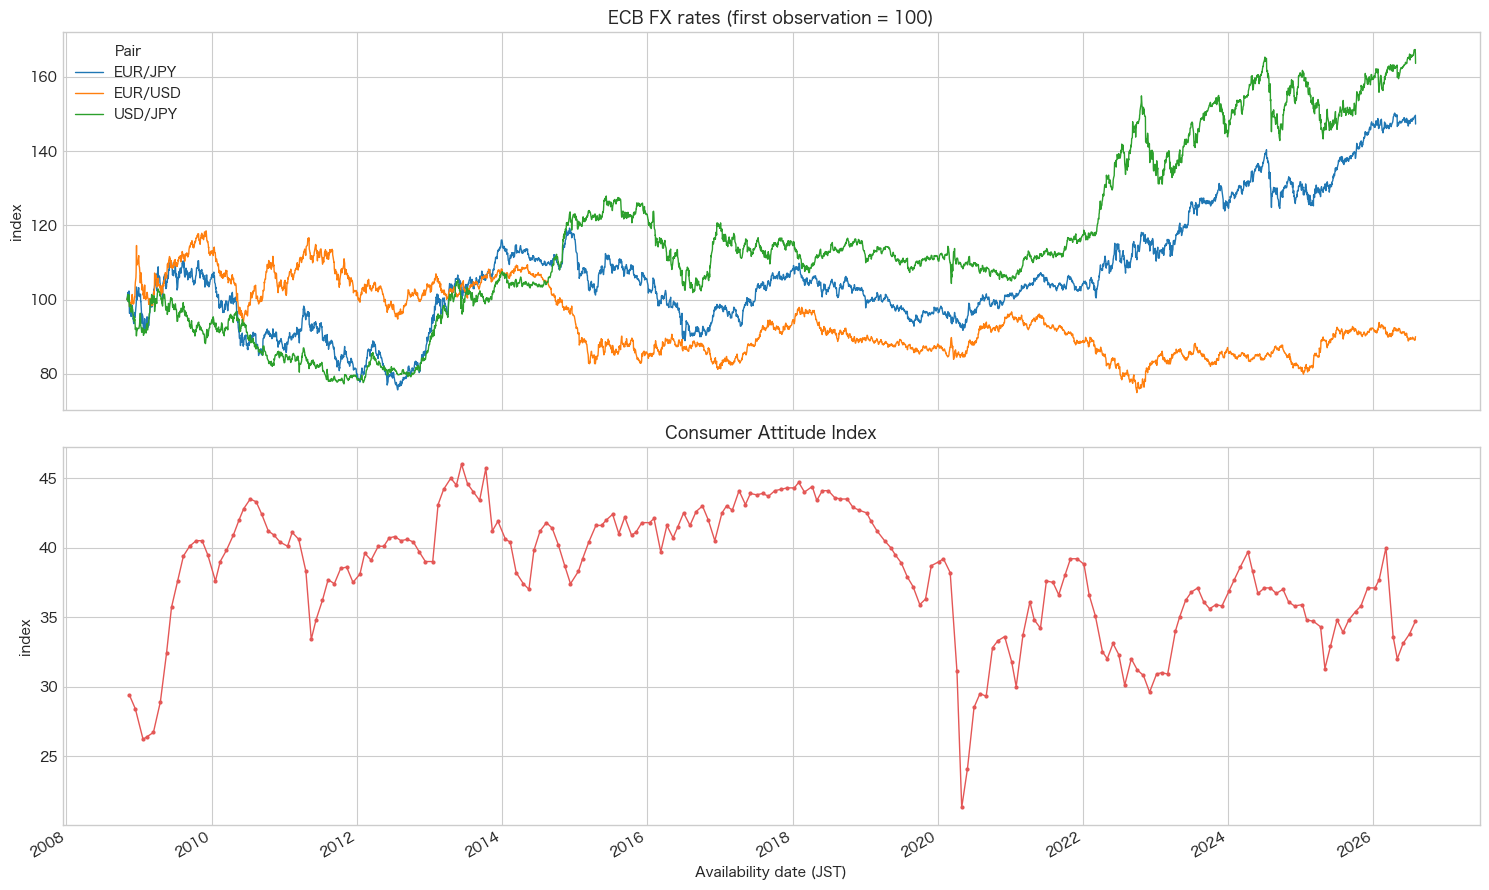

In [9]:
fx = pd.concat([
    pd.read_parquet(INPUT_DIR / "ecb_fx_rates_train.parquet"),
    pd.read_parquet(INPUT_DIR / "ecb_fx_rates_valid.parquet"),
]).sort_index()
consumer = pd.concat([
    pd.read_parquet(INPUT_DIR / "consumer_attitude_index_train.parquet"),
    pd.read_parquet(INPUT_DIR / "consumer_attitude_index_valid.parquet"),
]).sort_index()

print("FX sample — index Date is the availability timestamp:")
display(fx[["ObservationDate", "Rate", "IsDerived", "DatasetSplit"]].head(6))
print("Consumer index sample — ObservationDate and availability Date are different:")
display(consumer[["ObservationDate", "ConsumerAttitudeIndex", "PublishedAtJst", "DatasetSplit"]].head(6))

fx_wide = fx["Rate"].unstack("Pair").sort_index()
fx_normalized = fx_wide.divide(fx_wide.apply(lambda s: s.dropna().iloc[0])).multiply(100)
consumer_series = consumer["ConsumerAttitudeIndex"]

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fx_normalized.plot(ax=axes[0], lw=1)
axes[0].set(title="ECB FX rates (first observation = 100)", ylabel="index", xlabel="")
consumer_series.plot(ax=axes[1], color="#E45756", marker="o", ms=2, lw=1)
axes[1].set(title="Consumer Attitude Index", xlabel="Availability date (JST)", ylabel="index")
plt.tight_layout()
plt.show()


## 6. 外部データを使うときの注意

上記以外の外部データはコンペで使えます。ただし、次の3点を必ず確認してください。

### 先読みを防ぐ

- データは対象日ではなく、実際に公表されて利用できた日時で結合する。
- 後から改定される統計は、できるだけ当時の初報値を使う。
- 海外市場の終値は、日本で確認できる時刻より前には使わない。
- 現在の指数構成や株価を、そのまま過去に当てはめない。

### 欠損とデータ品質を確認する

- 欠損をすぐに削除したり0で埋めたりせず、休場や上場前などの理由を確認する。
- 値を補う場合は、未来の値を使わず、過去に分かっていた値だけを使う。

### 提出できる形にする

- 採点環境では通信できないため、必要なファイルは事前に取得して戦略フォルダに含める。
- 後から再現できるよう、取得時の生データと取得方法を残す。